# BirdCLEF++ 2026 — Train Baseline with TIMM⚡Pytorch & ONNX inference

Acoustic species identification in the Pantanal, South America.

**Pipeline:** Audio → log-mel spectrogram → EfficientNet-V2-S → species probabilities

**Stack:** PyTorch Lightning + TIMM + torchaudio + ONNX

**Key decisions from past winning solutions:**
- CE loss (not BCE) — single primary label per recording
- EfficientNet family as workhorse backbone
- 5s window, 32kHz, log-mel spectrograms
- ONNX export for CPU inference speed

Each section below contains a brief explanation of *why* we do things this way,
so the notebook doubles as an educational guide for BirdCLEF newcomers.

## Imports & Setup

We keep top-level imports minimal — only stdlib and the most essential packages.
Heavier / domain-specific imports are deferred to the section where they are
first needed so that individual cells stay self-contained and easy to re-run.

In [1]:
!pip install -q onnxscript onnxruntime pytorch-lightning # onnxruntime-gpu
!pip uninstall -y rich  # disable rich progress bar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 14.7 MB/s eta 0:00:00
Found existing installation: rich 13.9.4
Uninstalling rich-13.9.4:
  Successfully uninstalled rich-13.9.4


In [2]:
from __future__ import annotations

import logging
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
log = logging.getLogger(__name__)

## Global Constants

Every tunable knob lives here as a plain constant — no config dataclasses.
Functions reference these only as **default argument values**, never directly
in their body.  This keeps functions testable and re-usable with different
settings while still providing convenient defaults.

In [3]:
# === Paths (using the DATA_DIR defined by kagglehub) ===
import os
from pathlib import Path

DATA_DIR = Path("/kaggle/input/competitions/birdclef-2026")
# DATA_DIR is for reading only.
actual_data_path = Path(DATA_DIR)

# OUTPUT_DIR is for writing (checkpoints, logs, submissions).
# On Kaggle/Colab, "." points to the writable working directory.
OUTPUT_DIR: Path = Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# === Audio ===
SAMPLE_RATE: int = 32_000
WINDOW_SEC: float = 5.0
WINDOW_SAMPLES: int = int(SAMPLE_RATE * WINDOW_SEC)

# === Mel Spectrogram ===
N_FFT: int = 1024
HOP_LENGTH: int = 320
N_MELS: int = 128
FMIN: int = 20
FMAX: int = 16_000
TOP_DB: float = 80.0
TARGET_H: int = 224
TARGET_W: int = 224

# === Model ===
MODEL_NAME: str = "tf_efficientnetv2_s.in21k"
PRETRAINED: bool = True

# === Training ===
VAL_FRACTION: float = 0.20
EPOCHS: int = 25
BATCH_SIZE: int = 128
LR: float = 2e-3
WEIGHT_DECAY: float = 1e-4
NUM_WORKERS: int = os.cpu_count()
SEED: int = 42

## 1. EDA — Explore the Data

Before writing any model code we inspect the metadata:
- How many species?  How imbalanced are the classes?
- What audio durations do we have?
- Which column names does this year's edition use?

This step often reveals data-quality issues (e.g. species with <5 samples)
that inform augmentation and sampling decisions later.

In [4]:
def load_metadata(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Load training metadata CSV.

    We prioritize 'train.csv' for the iNat clips, falling back to other
    candidates if necessary.
    """
    csv_path = Path(data_dir) / "train.csv"
    if not csv_path.exists():
        csv_path = Path(data_dir) / "train_metadata.csv"

    if not csv_path.exists():
        candidates = list(Path(data_dir).glob("train*.csv"))
        if candidates:
            csv_path = candidates[0]
        else:
            raise FileNotFoundError(f"No train metadata CSV found in {data_dir}")

    df = pd.read_csv(csv_path)
    log.info("Using metadata: %s | Shape: %s", csv_path.name, df.shape)
    return df

def load_taxonomy(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Load taxonomy CSV if available."""
    tax_path = Path(data_dir) / "taxonomy.csv"
    if tax_path.exists():
        tax = pd.read_csv(tax_path)
        log.info("Taxonomy shape: %s", tax.shape)
        return tax
    return pd.DataFrame()

In [5]:
def detect_columns(df: pd.DataFrame) -> tuple[str, str]:
    """Auto-detect the species-label and filename columns.

    Returns ``(species_col, filename_col)``.
    """
    species_col = "primary_label"
    for col in ("primary_label", "species", "ebird_code", "label"):
        if col in df.columns:
            species_col = col
            break

    filename_col = "filename"
    for col in ("filename", "file_name", "filepath", "audio_path"):
        if col in df.columns:
            filename_col = col
            break

    log.info("Detected species_col=%r, filename_col=%r", species_col, filename_col)
    return species_col, filename_col

In [6]:
def run_eda(
    df: pd.DataFrame,
    species_col: str = "primary_label",
    output_dir: Path = OUTPUT_DIR,
) -> list[str]:
    """Print summary stats and plot class distribution.

    Returns a sorted list of unique species names — this becomes our label set.
    """
    import matplotlib.pyplot as plt

    species_list = sorted(df[species_col].unique().tolist())
    log.info("Number of species: %d", len(species_list))

    counts = df[species_col].value_counts()
    log.info(
        "Samples per species — min: %d, median: %d, max: %d",
        counts.min(),
        int(counts.median()),
        counts.max(),
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(counts.values, bins=50, edgecolor="black", alpha=0.7)
    axes[0].set_xlabel("Number of recordings")
    axes[0].set_ylabel("Number of species")
    axes[0].set_title("Class Distribution (Histogram)")

    axes[1].bar(range(len(counts)), counts.values, width=1.0, alpha=0.7)
    axes[1].set_xlabel("Species (sorted by count)")
    axes[1].set_ylabel("Number of recordings")
    axes[1].set_title("Class Distribution (Sorted)")

    plt.tight_layout()
    plt.savefig(output_dir / "eda_class_distribution.png", dpi=100, bbox_inches="tight")
    plt.show()

    for dur_col in ("duration", "length", "seconds"):
        if dur_col in df.columns:
            log.info(
                "Audio duration (s) — min: %.1f, median: %.1f, max: %.1f",
                df[dur_col].min(),
                df[dur_col].median(),
                df[dur_col].max(),
            )
            break

    return species_list

In [7]:
actual_data_dir = Path(DATA_DIR)
df = load_metadata(actual_data_dir)
species_col, filename_col = detect_columns(df)

total_samples = len(df)
unique_species = df[species_col].nunique()
val_size = int(total_samples * VAL_FRACTION)

print(f"Total samples: {total_samples}")
print(f"Unique species: {unique_species}")
print(f"Planned validation size: {val_size}")

if val_size < unique_species:
    print(f"ERROR: Validation size ({val_size}) is still smaller than number of species ({unique_species}).")
else:
    print("SUCCESS: Validation size is sufficient for a stratified split.")

INFO:__main__:Using metadata: train.csv | Shape: (35549, 15)
INFO:__main__:Detected species_col='primary_label', filename_col='filename'


Total samples: 35549
Unique species: 206
Planned validation size: 7109
SUCCESS: Validation size is sufficient for a stratified split.


## 2. Audio & Spectrogram Utilities

All BirdCLEF top solutions convert raw audio into **log-mel spectrograms**
and treat them as single-channel images fed into an ImageNet-pretrained CNN.

Key design choices:
- **32 kHz** sample rate (standard for bird audio, captures up to 16 kHz)
- **5-second window** — the atomic prediction unit in every BirdCLEF edition
- **Normalise waveform to unit std** before computing the spectrogram
  (proven technique from multiple top solutions)
- Resize the spectrogram to 224x224 so we can re-use ImageNet-pretrained
  weights without architectural changes

In [8]:
import torch.nn as nn
import torch.nn.functional as F


def load_audio(
    path: str | Path,
    target_sr: int = SAMPLE_RATE,
) -> torch.Tensor:
    """Load an audio file and resample to ``target_sr``.

    Returns a 1-D float tensor of shape ``(num_samples,)``.
    """
    import torchaudio

    waveform, sr = torchaudio.load(str(path))
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)(
            waveform
        )
    return waveform.squeeze(0)


def random_crop(
    waveform: torch.Tensor,
    window_samples: int = WINDOW_SAMPLES,
) -> torch.Tensor:
    """Extract a random segment of exactly ``window_samples`` length.

    Short waveforms are zero-padded on the right.
    """
    n = waveform.shape[0]
    if n <= window_samples:
        return F.pad(waveform, (0, window_samples - n))
    start = torch.randint(0, n - window_samples + 1, (1,)).item()
    return waveform[start : start + window_samples]


def sequential_crops(
    waveform: torch.Tensor,
    window_samples: int = WINDOW_SAMPLES,
) -> list[torch.Tensor]:
    """Split waveform into non-overlapping windows for inference.

    The last chunk is zero-padded if shorter than ``window_samples``.
    """
    crops: list[torch.Tensor] = []
    for start in range(0, waveform.shape[0], window_samples):
        chunk = waveform[start : start + window_samples]
        if chunk.shape[0] < window_samples:
            chunk = F.pad(chunk, (0, window_samples - chunk.shape[0]))
        crops.append(chunk)
    return crops

### MelSpectrogramTransform
#
A thin ``nn.Module`` that converts a raw waveform into a normalised
log-mel spectrogram image.  Encapsulating this as a module makes it easy
to share the exact same transform between training and inference.

In [9]:
class MelSpectrogramTransform(nn.Module):
    """Waveform → normalised log-mel spectrogram image.

    Output shape: ``(1, target_h, target_w)`` with values in ``[0, 1]``.
    The single channel is later repeated to 3 channels so that ImageNet
    pretrained weights see the expected input dimensionality.
    """

    def __init__(
        self,
        sample_rate: int = SAMPLE_RATE,
        n_fft: int = N_FFT,
        hop_length: int = HOP_LENGTH,
        n_mels: int = N_MELS,
        fmin: int = FMIN,
        fmax: int = FMAX,
        top_db: float = TOP_DB,
        target_h: int = TARGET_H,
        target_w: int = TARGET_W,
    ):
        super().__init__()
        import torchaudio

        self.mel_spec = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels,
            f_min=fmin,
            f_max=fmax,
            power=2.0,
        )
        self.amp_to_db = torchaudio.transforms.AmplitudeToDB(top_db=top_db)
        self.target_h = target_h
        self.target_w = target_w

    def forward(self, waveform: torch.Tensor) -> torch.Tensor:
        """``(num_samples,)`` → ``(1, H, W)`` normalised to [0, 1]."""
        spec = self.mel_spec(waveform.unsqueeze(0))  # (1, n_mels, T)
        spec = self.amp_to_db(spec)

        vmin, vmax = spec.min(), spec.max()
        spec = (spec - vmin) / (vmax - vmin + 1e-8)

        spec = F.interpolate(
            spec.unsqueeze(0),  # (1, 1, n_mels, T)
            size=(self.target_h, self.target_w),
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)  # (1, H, W)

        return spec

## 3. Dataset

A thin ``Dataset`` that:
1. Loads a single audio file
2. Extracts a random 5 s crop (train) or the first 5 s (val)
3. Normalises the waveform to unit standard deviation
4. Converts to a log-mel spectrogram
5. Repeats the single channel to 3 channels (ImageNet convention)

No heavy augmentations in this baseline — that is one of the first things
to add for a competitive solution (MixUp, SpecAugment, Gaussian noise, …).

In [10]:
from torch.utils.data import DataLoader, Dataset


class BirdCLEFDataset(Dataset):
    """Per-recording dataset for BirdCLEF training / validation."""

    def __init__(
        self,
        df: pd.DataFrame,
        species_list: list[str],
        audio_dir: Path,
        mel_transform: MelSpectrogramTransform,
        is_train: bool = True,
        soundscape_dir: Path | None = None,
        species_col: str = "primary_label",
        filename_col: str = "filename",
        window_samples: int = WINDOW_SAMPLES,
    ):
        self.df = df.reset_index(drop=True)
        self.species_to_idx: dict[str, int] = {
            s: i for i, s in enumerate(species_list)
        }
        self.audio_dir = audio_dir
        self.soundscape_dir = soundscape_dir
        self.mel_transform = mel_transform
        self.is_train = is_train
        self.species_col = species_col
        self.filename_col = filename_col
        self.window_samples = window_samples

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, int]:
        row = self.df.iloc[idx]
        label_name = row[self.species_col]
        label_idx = self.species_to_idx[label_name]

        # Root fix for path construction:
        # Metadata 'filename' usually includes the species folder (e.g. 'species/file.ogg')
        # So we join audio_dir directly with the filename column.
        filepath = self.audio_dir / row[self.filename_col]

        # Fallback for different folder structures if the above fails
        if not filepath.exists():
            folder_name = str(label_name).split(';')[0]
            filepath = self.audio_dir / folder_name / Path(row[self.filename_col]).name

        waveform = load_audio(filepath)

        if self.is_train:
            waveform = random_crop(waveform, window_samples=self.window_samples)
        else:
            waveform = waveform[: self.window_samples]
            if waveform.shape[0] < self.window_samples:
                waveform = F.pad(waveform, (0, self.window_samples - waveform.shape[0]))

        std = waveform.std()
        if std > 0:
            waveform = waveform / std

        spec = self.mel_transform(waveform)
        spec = spec.repeat(3, 1, 1)
        return spec, label_idx

In [11]:
species_counts = df[species_col].value_counts()
single_samples = species_counts[species_counts == 1]
print(f"Total unique species: {len(species_counts)}")
print(f"Species with only 1 sample: {len(single_samples)}")
if len(single_samples) > 0:
    display(single_samples.head())
else:
    print("Every species in the current DataFrame has at least 2 samples, which is why it works here!")

Total unique species: 206
Species with only 1 sample: 4


primary_label
516975    1
23724     1
116570    1
23150     1
Name: count, dtype: int64

## 4. Lightning DataModule
#
Wraps the train / val split and DataLoader creation.
#
We use a **simple random stratified split** instead of K-fold to keep the
baseline lean.  K-fold is absolutely worth adding later — every top solution
uses it — but a single split is enough to iterate quickly while the
competition is young.

In [12]:
from pytorch_lightning import LightningDataModule

class BirdCLEFDataModule(LightningDataModule):
    """Stratified train / val split with safety for single-sample classes."""

    def __init__(
        self,
        df: pd.DataFrame,
        species_list: list[str],
        audio_dir: Path,
        soundscape_dir: Path | None = None,
        val_fraction: float = VAL_FRACTION,
        batch_size: int = BATCH_SIZE,
        num_workers: int = NUM_WORKERS,
        seed: int = SEED,
        species_col: str = "primary_label",
        filename_col: str = "filename",
    ):
        super().__init__()
        self.df = df
        self.species_list = species_list
        self.audio_dir = audio_dir
        self.soundscape_dir = soundscape_dir
        self.val_fraction = val_fraction
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.seed = seed
        self.species_col = species_col
        self.filename_col = filename_col
        self.mel_transform = MelSpectrogramTransform()

    def setup(self, stage: str | None = None) -> None:
        from sklearn.model_selection import train_test_split

        # 1. Identify species with only one sample
        counts = self.df[self.species_col].value_counts()
        single_sample_species = counts[counts < 2].index
        is_single = self.df[self.species_col].isin(single_sample_species)

        if is_single.any():
            # Move single-sample species to training set only, as they can't be stratified
            df_multi = self.df[~is_single]
            df_single = self.df[is_single]

            train_df, val_df = train_test_split(
                df_multi,
                test_size=self.val_fraction,
                random_state=self.seed,
                stratify=df_multi[self.species_col],
            )
            train_df = pd.concat([train_df, df_single], ignore_index=True)
            log.warning(f"Moved {is_single.sum()} single-sample species to the training set to allow stratification.")
        else:
            train_df, val_df = train_test_split(
                self.df,
                test_size=self.val_fraction,
                random_state=self.seed,
                stratify=self.df[self.species_col],
            )

        log.info(f"Split: train={len(train_df)}, val={len(val_df)}")

        common_kw = dict(
            species_list=self.species_list,
            audio_dir=self.audio_dir,
            soundscape_dir=self.soundscape_dir,
            mel_transform=self.mel_transform,
            species_col=self.species_col,
            filename_col=self.filename_col,
        )
        self.train_ds = BirdCLEFDataset(df=train_df, is_train=True, **common_kw)
        self.val_ds = BirdCLEFDataset(df=val_df, is_train=False, **common_kw)

    def train_dataloader(self) -> DataLoader:
        return DataLoader(
            self.train_ds,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            drop_last=True,
        )

    def val_dataloader(self) -> DataLoader:
        return DataLoader(
            self.val_ds,
            batch_size=self.batch_size * 2,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
        )

## 5. Model

We use **EfficientNet-V2-S** (pretrained on ImageNet-21k) from the TIMM
library.  This is a step up from the ubiquitous EfficientNet-B0 baseline
while still being comfortably fast enough for CPU inference via ONNX.

Architecture choices informed by past winners:
- **CE loss** (not BCE) — almost all training samples have exactly one
  primary label, so multi-class CE consistently outperforms binary CE.
- **Macro AUROC** as the tracking metric — aligns with the competition's
  threshold-free evaluation.
- **CosineAnnealingLR** — smooth learning-rate decay, used by virtually
  every top BirdCLEF solution.

In [13]:
import timm
from pytorch_lightning import LightningModule
from torchmetrics.classification import MulticlassAUROC, MulticlassAccuracy, MulticlassF1Score


class BirdCLEFModel(LightningModule):
    """TIMM image classifier with CE loss and multi-metric tracking."""

    def __init__(
        self,
        model_name: str = MODEL_NAME,
        num_classes: int = 100,
        pretrained: bool = PRETRAINED,
        lr: float = LR,
        weight_decay: float = WEIGHT_DECAY,
        epochs: int = EPOCHS,
    ):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs

        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            in_chans=3,
            num_classes=num_classes,
        )

        # Standard metrics for multi-class
        self.train_auroc = MulticlassAUROC(num_classes=num_classes, average="macro")
        self.val_auroc = MulticlassAUROC(num_classes=num_classes, average="macro")

        # Top-k accuracy and F1 are often more informative than AUROC
        self.val_acc = MulticlassAccuracy(num_classes=num_classes, top_k=1)
        self.val_acc5 = MulticlassAccuracy(num_classes=num_classes, top_k=5)
        self.val_f1 = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.backbone(x)

    def _shared_step(
        self,
        batch: tuple[torch.Tensor, torch.Tensor],
        stage: str,
    ) -> torch.Tensor:
        images, labels = batch
        logits = self(images)
        loss = F.cross_entropy(logits, labels)
        probs = F.softmax(logits, dim=1)

        self.log(f"{stage}_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

        if stage == "train":
            self.train_auroc.update(probs, labels)
        else:
            self.val_auroc.update(probs, labels)
            self.val_acc.update(probs, labels)
            self.val_acc5.update(probs, labels)
            self.val_f1.update(probs, labels)
        return loss

    def training_step(
        self,
        batch: tuple[torch.Tensor, torch.Tensor],
        batch_idx: int,
    ) -> torch.Tensor:
        return self._shared_step(batch, "train")

    def validation_step(
        self,
        batch: tuple[torch.Tensor, torch.Tensor],
        batch_idx: int,
    ) -> None:
        self._shared_step(batch, "val")

    def on_train_epoch_end(self) -> None:
        self.log("train_auroc", self.train_auroc.compute(), prog_bar=True)
        self.train_auroc.reset()

    def on_validation_epoch_end(self) -> None:
        self.log("val_auroc", self.val_auroc.compute(), prog_bar=True)
        self.log("val_acc", self.val_acc.compute(), prog_bar=True)
        self.log("val_acc5", self.val_acc5.compute(), prog_bar=True)
        self.log("val_f1", self.val_f1.compute(), prog_bar=True)
        self.val_auroc.reset()
        self.val_acc.reset()
        self.val_acc5.reset()
        self.val_f1.reset()

    def configure_optimizers(self) -> dict:
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay,
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.epochs,
            eta_min=1e-6,
        )
        return {"optimizer": optimizer, "lr_scheduler": scheduler}

## 6. Training

A single training run with the best checkpoint selected by ``val_auroc``.
The function is fully parameterised so you can later loop over folds or
hyper-parameter sweeps without touching the implementation.

In [14]:
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

def train(
    df: pd.DataFrame,
    species_list: list[str],
    audio_dir: Path,
    species_col: str = "primary_label",
    filename_col: str = "filename",
    val_fraction: float = VAL_FRACTION,
    batch_size: int = BATCH_SIZE,
    epochs: int = EPOCHS,
    lr: float = LR,
    seed: int = SEED,
    output_dir: Path = OUTPUT_DIR,
) -> BirdCLEFModel:
    """Train a single model and return the best checkpoint."""
    seed_everything(seed)

    num_classes = len(species_list)
    log.info("Training: num_classes=%d, epochs=%d, lr=%s", num_classes, epochs, lr)

    dm = BirdCLEFDataModule(
        df=df,
        species_list=species_list,
        audio_dir=audio_dir,
        val_fraction=val_fraction,
        batch_size=batch_size,
        seed=seed,
        species_col=species_col,
        filename_col=filename_col,
    )

    model = BirdCLEFModel(num_classes=num_classes, lr=lr, epochs=epochs)

    checkpoint_cb = ModelCheckpoint(
        dirpath=output_dir / "checkpoints",
        filename="best-{epoch:02d}-{val_auroc:.4f}",
        monitor="val_auroc",
        mode="max",
        save_top_k=1,
    )
    lr_monitor = LearningRateMonitor(logging_interval="epoch")
    csv_logger = CSVLogger(save_dir=str(output_dir), name="logs")

    trainer = Trainer(
        max_epochs=epochs,
        accelerator="auto",
        precision="16-mixed" if torch.cuda.is_available() else "32-true",
        callbacks=[checkpoint_cb, lr_monitor],
        logger=csv_logger,
        log_every_n_steps=20,
        deterministic=False,
        default_root_dir=str(output_dir),
    )

    trainer.fit(model, dm)

    best_path = checkpoint_cb.best_model_path
    log.info(
        "Best checkpoint: %s (val_auroc=%.4f)",
        best_path,
        checkpoint_cb.best_model_score,
    )
    return BirdCLEFModel.load_from_checkpoint(best_path, num_classes=num_classes)

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_progress(output_dir: Path = OUTPUT_DIR):
    sns.set_theme(style="whitegrid")

    log_files = list(output_dir.glob("logs/version_*/metrics.csv"))
    if not log_files:
        print("No log files found yet. Run the training cell first.")
        return
    log_path = max(log_files, key=lambda p: int(p.parent.name.split('_')[1]))

    metrics = pd.read_csv(log_path)
    display(metrics.head())

    # Sort by step if available to ensure correct time sequence
    if "step" in metrics.columns:
        metrics = metrics.sort_values("step")

    # Identify which columns we can use for the x-axis identifiers
    possible_ids = ["step", "epoch"]
    id_vars = [col for col in possible_ids if col in metrics.columns]

    if not id_vars:
        print("No time-axis columns (epoch/step) found in logs yet.")
        return

    # Use the first available ID as the primary X axis for plotting
    time_col = id_vars[0]

    metrics_melted = metrics.melt(id_vars=id_vars, var_name='metric', value_name='value').dropna()

    # Plot 1: Loss
    plt.figure(figsize=(10, 4))
    loss_data = metrics_melted[metrics_melted['metric'].str.contains('loss')]
    if not loss_data.empty:
        sns.lineplot(data=loss_data, x=time_col, y='value', hue='metric', marker='o')
        plt.title('Loss Over Time', fontsize=12, fontweight='bold')
        plt.show()

    # Plot 2: All 0-1 Metrics (AUROC, Accuracy, F1)
    plt.figure(figsize=(10, 4))
    perf_metrics = ["auroc", "acc", "f1"]
    perf_data = metrics_melted[metrics_melted['metric'].str.contains('|'.join(perf_metrics))]

    if not perf_data.empty:
        sns.lineplot(data=perf_data, x=time_col, y='value', hue='metric', marker='o')
        plt.title('Performance Metrics (0-1 Scale)', fontsize=12, fontweight='bold')
        plt.ylim(0, 1.05)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.show()

## 7. ONNX Export

BirdCLEF is a **CPU-only code competition** with a strict time limit
(90 min in 2025, 120 min in 2023–2024).  Exporting to ONNX with graph
optimisations gives a significant speed-up over raw PyTorch inference.
The 2023 top-24 solution reported fitting 5 ensemble models into the
time budget *only* because of ONNX + graph optimisation.

In [16]:
def export_onnx(
    model: BirdCLEFModel,
    onnx_path: Path = OUTPUT_DIR / "model.onnx",
    target_h: int = TARGET_H,
    target_w: int = TARGET_W,
) -> Path:
    """Export trained model to ONNX for fast CPU inference."""
    model.eval()
    model.cpu()
    dummy = torch.randn(1, 3, target_h, target_w)

    torch.onnx.export(
        model,
        dummy,
        str(onnx_path),
        opset_version=18,
        input_names=["input"],
        output_names=["logits"],
        dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
    )
    log.info("ONNX exported: %s (%.1f MB)", onnx_path, onnx_path.stat().st_size / 1e6)
    return onnx_path

## 8. Inference

At test time we:
1. Load each soundscape file (typically 1–10 minutes long)
2. Slice it into non-overlapping 5 s windows
3. Compute the mel spectrogram for each window
4. Batch-predict with the ONNX model
5. Apply softmax to get per-species probabilities

The output is one row per window with a ``row_id`` of the form
``{soundscape_id}_{end_time_seconds}`` — matching the submission format.

In [17]:
def load_onnx_session(onnx_path: Path = OUTPUT_DIR / "model.onnx"):
    """Create an ONNX Runtime session with GPU support and CPU fallback."""
    import onnxruntime as ort

    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

    # Order determines priority: CUDA first, then CPU
    providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]

    # Filter available providers
    available_providers = ort.get_available_providers()
    active_providers = [p for p in providers if p in available_providers]

    session = ort.InferenceSession(
        str(onnx_path), opts, providers=active_providers
    )
    log.info("ONNX session loaded with providers: %s", active_providers)
    return session

In [18]:
def predict_soundscape(
    audio_path: str | Path,
    session,
    mel_transform: MelSpectrogramTransform,
    species_list: list[str],
    sample_rate: int = SAMPLE_RATE,
    window_samples: int = WINDOW_SAMPLES,
    window_sec: float = WINDOW_SEC,
    batch_size: int = 1,
) -> pd.DataFrame:
    """Run inference on a single soundscape file using a batch size of 1.

    Returns a DataFrame with columns ``[row_id, species_1, species_2, …]``.
    """
    waveform = load_audio(audio_path, target_sr=sample_rate)
    crops = sequential_crops(waveform, window_samples=window_samples)
    soundscape_id = Path(audio_path).stem

    all_probs: list[np.ndarray] = []
    for crop in crops:
        std = crop.std()
        if std > 0:
            crop = crop / std

        # Prepare single-item batch (1, 3, H, W)
        spec = mel_transform(crop).repeat(3, 1, 1).unsqueeze(0)
        batch_np = spec.numpy()

        logits = session.run(None, {"input": batch_np})[0]
        exp_l = np.exp(logits - logits.max(axis=1, keepdims=True))
        all_probs.append(exp_l / exp_l.sum(axis=1, keepdims=True))

    probs = np.concatenate(all_probs, axis=0)

    rows = []
    for win_idx in range(len(probs)):
        end_time = int((win_idx + 1) * window_sec)
        row = {"row_id": f"{soundscape_id}_{end_time}"}
        for sp_idx, sp_name in enumerate(species_list):
            row[sp_name] = float(probs[win_idx, sp_idx])
        rows.append(row)

    return pd.DataFrame(rows)

In [19]:
def run_inference(
    test_dir: Path,
    session,
    species_list: list[str],
    data_dir: Path = DATA_DIR,
    sample_rate: int = SAMPLE_RATE,
    window_samples: int = WINDOW_SAMPLES,
    window_sec: float = WINDOW_SEC,
    subset: Optional[int] = None,
) -> pd.DataFrame:
    """Run inference on every soundscape in ``test_dir`` with a progress bar."""
    mel_transform = MelSpectrogramTransform()

    test_files = sorted(
        list(test_dir.glob("*.ogg"))
        + list(test_dir.glob("*.wav"))
        + list(test_dir.glob("*.flac"))
        + list(test_dir.glob("*.mp3"))
    )[:subset]
    log.info("Found %d test soundscape files", len(test_files))

    all_preds = []
    for fpath in tqdm(test_files, desc="Inference Progress"):
        preds = predict_soundscape(
            audio_path=fpath,
            session=session,
            mel_transform=mel_transform,
            species_list=species_list,
            sample_rate=sample_rate,
            window_samples=window_samples,
            window_sec=window_sec,
        )
        all_preds.append(preds)

    if all_preds:
        return pd.concat(all_preds, ignore_index=True)

    log.warning("No test files — falling back to sample_submission.csv")
    sample_path = data_dir / "sample_submission.csv"
    if sample_path.exists():
        return pd.read_csv(sample_path)
    return pd.DataFrame(columns=["row_id"] + species_list)

## 9. Submission Formatting
#
Kaggle expects the submission CSV to have *exactly* the columns from
``sample_submission.csv``.  We align our predictions to that schema:
fill missing species with 0.0 and drop any extra columns.

In [20]:
def format_submission(
    submission: pd.DataFrame,
    data_dir: Path = DATA_DIR,
    output_dir: Path = OUTPUT_DIR,
    sample_submission_path: Path | None = None,
) -> Path:
    """Align columns with sample_submission.csv and save."""
    if sample_submission_path is None:
        sample_submission_path = data_dir / "sample_submission.csv"

    if sample_submission_path.exists():
        expected_cols = list(pd.read_csv(sample_submission_path).columns)
        for col in expected_cols:
            if col not in submission.columns and col != "row_id":
                submission[col] = 0.0
        submission = submission[expected_cols]
        log.info("Submission aligned to %d columns", len(expected_cols))

    out_path = output_dir / "submission.csv"
    submission.to_csv(out_path, index=False)
    log.info("Submission saved: %s (%d rows)", out_path, len(submission))
    return out_path

## 10. Main — Run Everything

The full pipeline in one call:

1. **EDA** — load metadata, inspect class distribution
2. **Train** — fit EfficientNet-V2-S with CE loss
3. **Export** — convert best checkpoint to ONNX
4. **Infer** — predict on test soundscapes
5. **Submit** — format and save ``submission.csv``

### Step 1 — Load data & EDA

INFO:__main__:Using metadata: train.csv | Shape: (35549, 15)
INFO:__main__:Taxonomy shape: (234, 5)
INFO:__main__:Detected species_col='primary_label', filename_col='filename'
INFO:__main__:Number of species: 206
INFO:__main__:Samples per species — min: 1, median: 125, max: 499


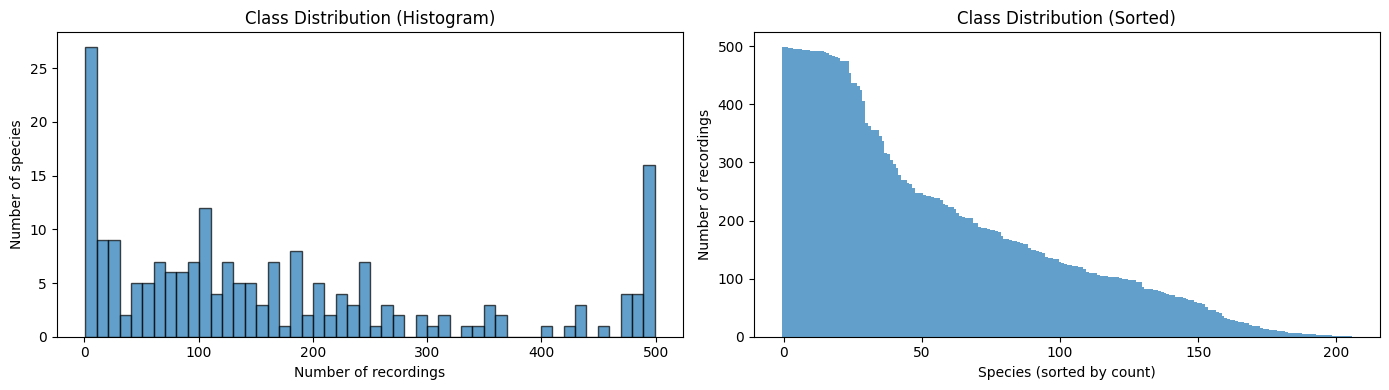

Audio clips directory: /kaggle/input/competitions/birdclef-2026/train_audio
Soundscapes directory: /kaggle/input/competitions/birdclef-2026/train_soundscapes
SUCCESS: Found first audio file at /kaggle/input/competitions/birdclef-2026/train_audio/1161364/iNat1216197.ogg


In [21]:
actual_data_dir = Path(DATA_DIR)

df = load_metadata(actual_data_dir)
_ = load_taxonomy(actual_data_dir)
species_col, filename_col = detect_columns(df)
species_list = run_eda(df, species_col=species_col)

# train_audio: folder with subfolders for each species
audio_dir = actual_data_dir / "train_audio"
# train_soundscapes: folder with long recordings (often used for validation/testing)
soundscape_dir = actual_data_dir / "train_soundscapes"

if not audio_dir.exists():
    audio_dir = actual_data_dir

print(f"Audio clips directory: {audio_dir}")
print(f"Soundscapes directory: {soundscape_dir if soundscape_dir.exists() else 'Not found'}")

row = df.iloc[0]
test_path = audio_dir / row[filename_col]
if not test_path.exists():
    test_path = audio_dir / row[species_col] / row[filename_col]

if test_path.exists():
    print(f"SUCCESS: Found first audio file at {test_path}")
else:
    print(f"WARNING: Could not find audio file for {row[species_col]} at {test_path}")

INFO:__main__:Split: train=28440, val=7109


Batch Specs shape: torch.Size([8, 3, 224, 224])
Batch Labels shape: torch.Size([8])


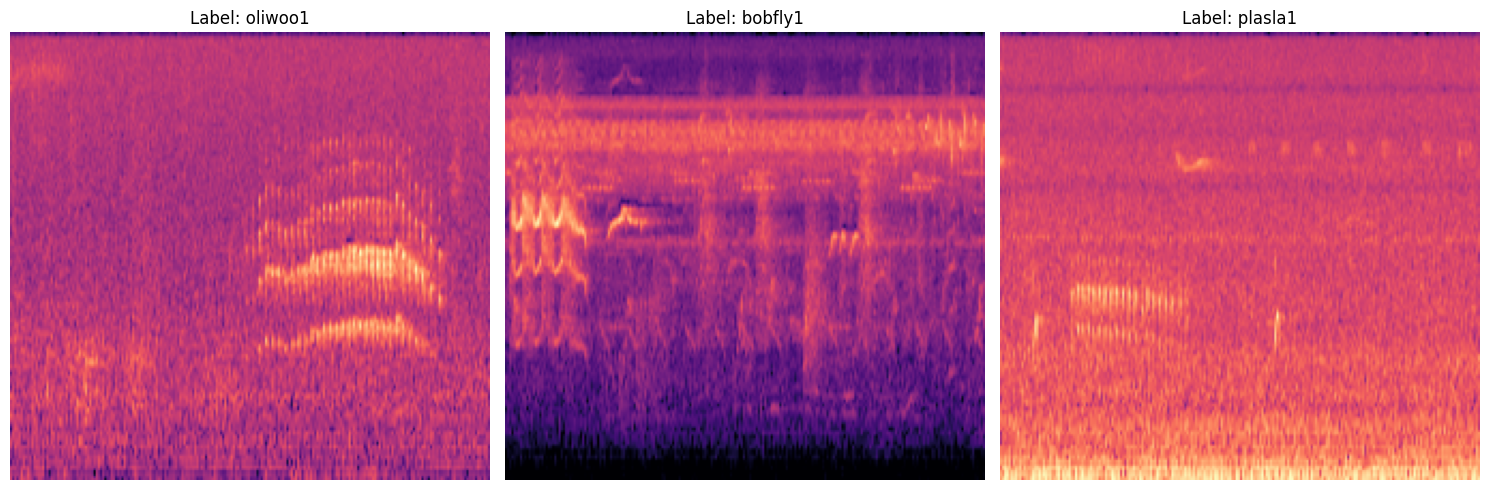

In [22]:
import matplotlib.pyplot as plt

# The DataModule now handles single-sample species internally!
dm = BirdCLEFDataModule(
    df=df,
    species_list=species_list,
    audio_dir=audio_dir,
    soundscape_dir=soundscape_dir,
    batch_size=8,
    num_workers=0
)
dm.setup()

# Get the first batch
train_loader = dm.train_dataloader()
batch_specs, batch_labels = next(iter(train_loader))

print(f"Batch Specs shape: {batch_specs.shape}")
print(f"Batch Labels shape: {batch_labels.shape}")

# Visualize 3 samples
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    spec = batch_specs[i][0].numpy()
    label_idx = batch_labels[i].item()
    axes[i].imshow(spec, origin='lower', aspect='auto', cmap='magma')
    axes[i].set_title(f"Label: {species_list[label_idx]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Step 2 — Train

INFO:__main__:Original df shape: (35549, 15)
INFO:__main__:Filtered df shape: (35545, 15), New number of species: 202
INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:__main__:Training: num_classes=202, epochs=25, lr=0.002
INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/tf_efficientnetv2_s.in21k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/tf_efficientnetv2_s.in21k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/timm/tf_efficientnetv2_s.in21k/xet-read-token/91e43067637cfaf6f3d55d927a7d6a96a481ff8c "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/193M [00:00<?, ?B/s]

INFO:timm.models._hub:[timm/tf_efficientnetv2_s.in21k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Missing keys (classifier.weight, classifier.bias) discovered while loading pretrained weights. This is expected if model is being adapted.
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:__main__:Split: train=28436, val=7109
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lig

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=25` reached.
INFO:__main__:Best checkpoint: /kaggle/working/checkpoints/best-epoch=17-val_auroc=0.9730.ckpt (val_auroc=0.9730)
INFO:timm.models._builder:Loading pretrained weights from Hugging Face hub (timm/tf_efficientnetv2_s.in21k)
INFO:httpx:HTTP Request: HEAD https://huggingface.co/timm/tf_efficientnetv2_s.in21k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
INFO:timm.models._hub:[timm/tf_efficientnetv2_s.in21k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
INFO:timm.models._builder:Missing keys (classifier.weight, classifier.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


,epoch,lr-AdamW,step,train_auroc,train_loss,val_acc,val_acc5,val_auroc,val_f1,val_loss
0,NaN,0.002000,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,NaN,221,NaN,NaN,0.372694,0.600229,0.947064,0.382184,2.083527
2,0.0,NaN,221,0.875905,3.031579,NaN,NaN,NaN,NaN,NaN
3,NaN,0.001992,222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.0,NaN,443,NaN,NaN,0.499514,0.716346,0.957675,0.501349,1.666380


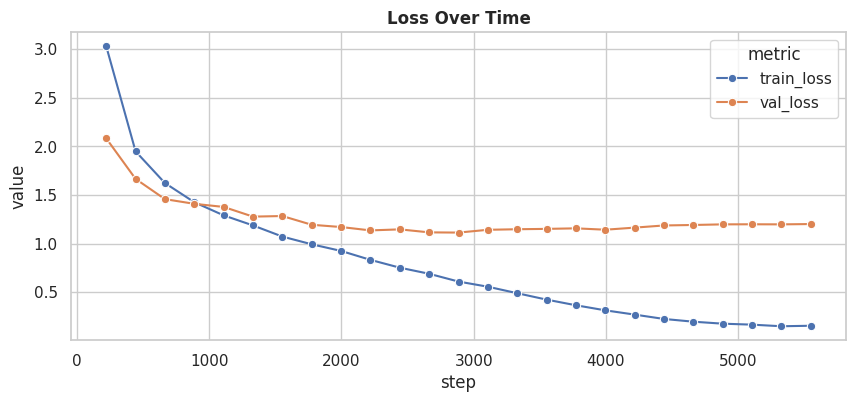

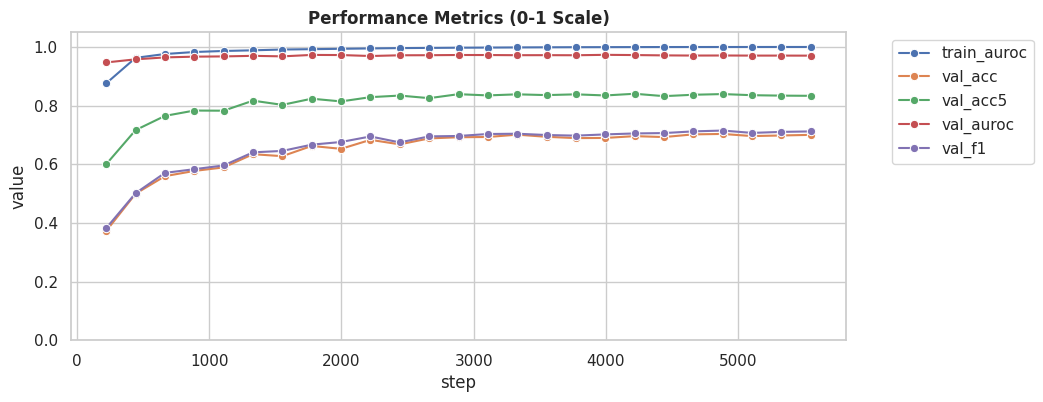

In [23]:
log.info("Original df shape: %s", df.shape)
# Identify and filter out species with only one sample to ensure stratified split works
species_counts = df[species_col].value_counts()
single_sample_species = species_counts[species_counts == 1].index.tolist()
if single_sample_species:
    log.warning("Filtering out %d species with only 1 sample for stratified split: %s",
                len(single_sample_species), single_sample_species)
    df = df[~df[species_col].isin(single_sample_species)]
    # Re-generate species_list based on the filtered DataFrame
    species_list = sorted(df[species_col].unique().tolist())
    log.info("Filtered df shape: %s, New number of species: %d", df.shape, len(species_list))

model = train(
    df=df,
    species_list=species_list,
    audio_dir=audio_dir,
    species_col=species_col,
    filename_col=filename_col,
)

plot_progress()

### Step 3 — ONNX Export

In [24]:
onnx_path = export_onnx(model, onnx_path=OUTPUT_DIR / "model.onnx")

W0315 20:02:42.363000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0315 20:02:42.365000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0315 20:02:42.367000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0315 20:02:42.369000 24 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `BirdCLEFModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `BirdCLEFModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


INFO:onnx_ir.passes.common.unused_removal:Removed 993 unused nodes
INFO:onnx_ir.passes.common.unused_removal:Removed 2 unused functions
INFO:onnxscript.optimizer._constant_folding:Skipping constant folding for node 'node_pad' because it is graph input to preserve graph signature


[torch.onnx] Translate the graph into ONNX... ✅


INFO:onnx_ir.passes.common.unused_removal:Removed 826 unused nodes
INFO:onnx_ir.passes.common.unused_removal:No unused functions to remove
INFO:onnxscript.optimizer._constant_folding:Skipping constant folding for node 'node_Conv_1724' because it is graph input to preserve graph signature


Applied 225 of general pattern rewrite rules.


INFO:onnx_ir.passes.common.unused_removal:No unused functions to remove
INFO:onnx_ir.passes._pass_infra:PassManager: No more graph changes detected after step 1
INFO:onnx_ir.passes.common.initializer_deduplication:Replaced initializer 'val_295' with existing initializer 'val_257'
INFO:onnx_ir.passes.common.initializer_deduplication:Replaced initializer 'val_333' with existing initializer 'val_257'
INFO:onnx_ir.passes.common.initializer_deduplication:Replaced initializer 'val_371' with existing initializer 'val_257'
INFO:onnx_ir.passes.common.initializer_deduplication:Replaced initializer 'val_409' with existing initializer 'val_257'
INFO:onnx_ir.passes.common.initializer_deduplication:Replaced initializer 'val_447' with existing initializer 'val_257'
INFO:onnx_ir.passes.common.initializer_deduplication:Replaced initializer 'val_485' with existing initializer 'val_257'
INFO:onnx_ir.passes.common.initializer_deduplication:Replaced initializer 'val_523' with existing initializer 'val_257'

### Step 4 — Inference

In [25]:
test_dir = Path(DATA_DIR) / "test_soundscapes"

# Kaggle standard: use test_soundscapes if it has files, otherwise fall back to train
if not any(test_dir.glob("*.ogg")):
    log.warning("test_soundscapes is empty or missing, using train_soundscapes for inference demonstration.")
    test_dir = Path(DATA_DIR) / "train_soundscapes"

# Safely resolve the path to the ONNX model
model_path = onnx_path if "onnx_path" in globals() else OUTPUT_DIR / "model.onnx"

session = load_onnx_session(onnx_path=model_path)
submission = run_inference(
    test_dir=test_dir,
    session=session,
    species_list=species_list,
    # subset=100,
)

INFO:__main__:ONNX session loaded with providers: ['CPUExecutionProvider']
INFO:__main__:Found 10658 test soundscape files


Inference Progress:   0%|          | 0/10658 [00:00<?, ?it/s]

### Step 5 — Save Submission

In [26]:
sub_path = format_submission(submission)
log.info("Done! Submission at %s", sub_path)

INFO:__main__:Submission aligned to 235 columns
INFO:__main__:Submission saved: submission.csv (137740 rows)
INFO:__main__:Done! Submission at submission.csv
